<a href="https://colab.research.google.com/github/Amii-1478/CodeAlpha_FinancialHealthDashboard/blob/main/KMeans_Clustering_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## **Upload Dataset**

In [7]:
df=pd.read_csv('Instagram visits clustering.csv')
df

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397
...,...,...,...
2595,2595,25,25.745908
2596,2596,52,9.275066
2597,2597,100,84.999487
2598,2598,87,20.530806


# **Clean Dataset**

**1.View First Rows**

In [8]:
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


**2.Check Dataset Information**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2600 non-null   int64  
 1   Instagram visit score    2600 non-null   int64  
 2   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 61.1 KB


****

**3.Check Missing Values**

In [10]:
df.isnull().sum()

,0
User ID,0
Instagram visit score,0
Spending_rank(0 to 100),0


**4.Remove Missing Values**

In [11]:
df = df.dropna()

**5.Check Duplicate Rows**

In [12]:
df.duplicated().sum()

np.int64(0)

**6.Remove Duplicates**

In [13]:
df = df.drop_duplicates()

**7.Check Column Names**

In [14]:
df.columns

Index(['User ID', 'Instagram visit score', 'Spending_rank(0 to 100)'], dtype='object')

**8.Clean Column Names**

In [15]:
df.columns = df.columns.str.strip()

**9.Detect Outliers**

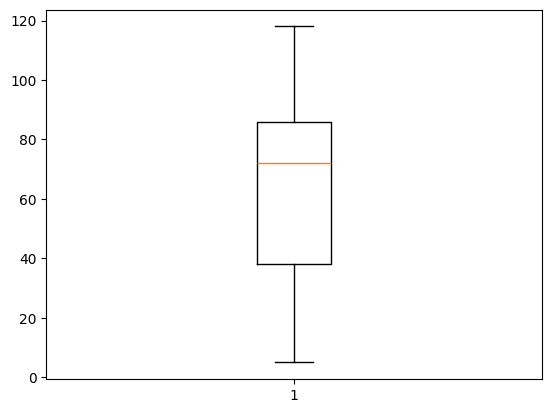

In [16]:
import matplotlib.pyplot as plt

plt.boxplot(df['Instagram visit score'])
plt.show()

**10.Remove Outliers**

In [17]:
Q1 = df['Instagram visit score'].quantile(0.25)
Q3 = df['Instagram visit score'].quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~((df['Instagram visit score'] < (Q1 - 1.5 * IQR)) |
      (df['Instagram visit score'] > (Q3 + 1.5 * IQR)))
]

**11.Check Final Shape**

In [18]:
df.shape

(2600, 3)

**12.Save Cleaned Dataset**

In [19]:
df.to_csv('cleaned_dataset.csv', index=False)

# **K-Means Clustering**

**Check Column Names**

In [20]:
df.columns

Index(['User ID', 'Instagram visit score', 'Spending_rank(0 to 100)'], dtype='object')

**Select Features**

In [21]:
X = df[['Instagram visit score', 'Spending_rank(0 to 100)']]

**Import Required Libraries**

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

**Scale the Data**

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Apply Elbow Method**

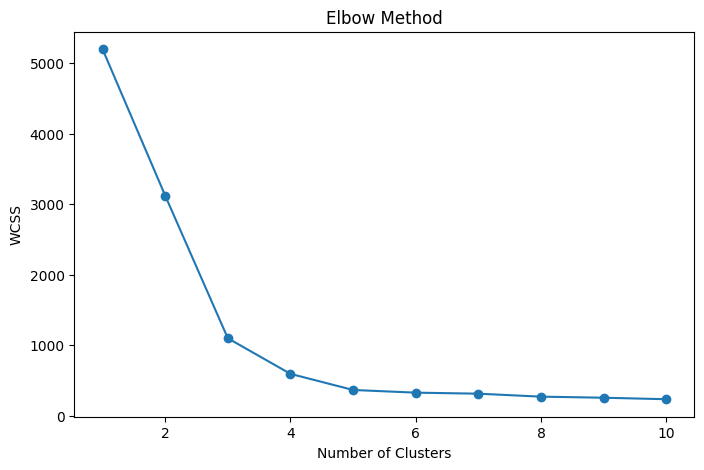

In [24]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

**Observe Elbow Point**

In [25]:
3

3

# **Train K-Means Model**

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

**View Clustered Data**(Now a new column appears:

Cluster)

In [27]:
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100),Cluster
0,0,63,24.050708,0
1,1,61,25.223290,0
2,2,104,18.528245,0
3,3,82,86.890232,2
4,4,14,31.492397,1


**Visualize Clusters**

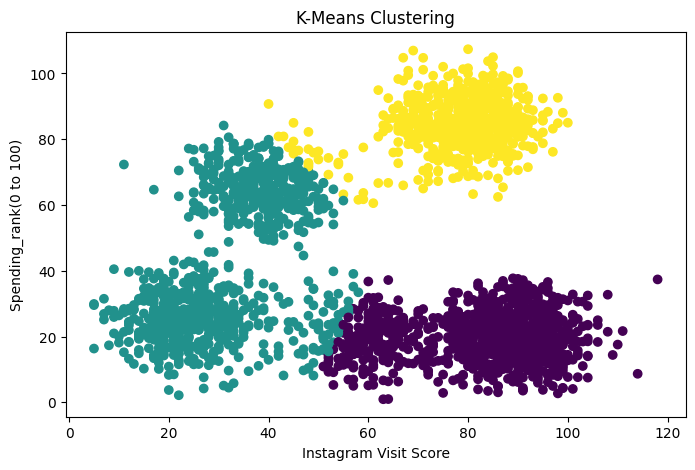

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Instagram visit score'],
    df['Spending_rank(0 to 100)'],
    c=df['Cluster']
)

plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending_rank(0 to 100)")
plt.title("K-Means Clustering")

plt.show()

Interpret Results

Example:

Cluster	Meaning

0	High visitors, high spending

1	Medium users

2	Low engagement users

**Save Final Dataset**

In [30]:
df.to_csv('clustered_dataset.csv', index=False)